In [1]:
from google.colab import files
uploaded = files.upload()

Saving PJME_hourly.csv to PJME_hourly.csv


In [2]:
import pandas as pd

df = pd.read_csv("PJME_hourly.csv")
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [3]:
import pandas as pd

df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime')

In [4]:
df.set_index('Datetime', inplace=True)
df.head()

,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


In [5]:
daily = df.resample('D').sum()
daily.head()

,PJME_MW
Datetime,
2002-01-01,714857.0
2002-01-02,822277.0
2002-01-03,828285.0
2002-01-04,809171.0
2002-01-05,729723.0


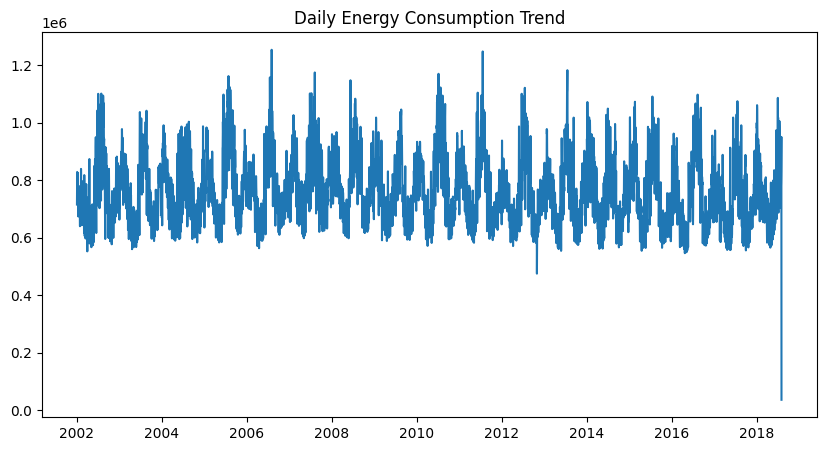

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(daily.index, daily['PJME_MW'])
plt.title("Daily Energy Consumption Trend")
plt.show()

In [7]:
!pip install prophet

In [8]:
from prophet import Prophet

data = daily.reset_index()[['Datetime','PJME_MW']]
data.columns = ['ds','y']

In [9]:
model = Prophet()
model.fit(data)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [10]:
future = model.make_future_dataframe(periods=365)
forecast = model.predict(future)

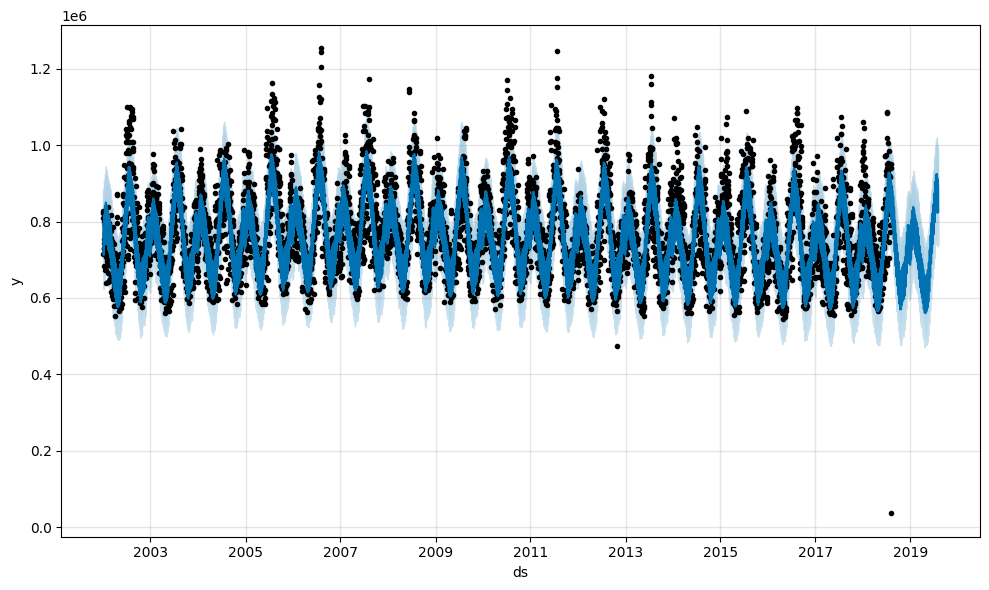

In [11]:
model.plot(forecast)
plt.show()